# 2.1 Transit light curve analysis of WASP-12b 

Guillermo de la Mata Núñez

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

C:\Users\Usuario\anaconda3\envs\pytransit_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

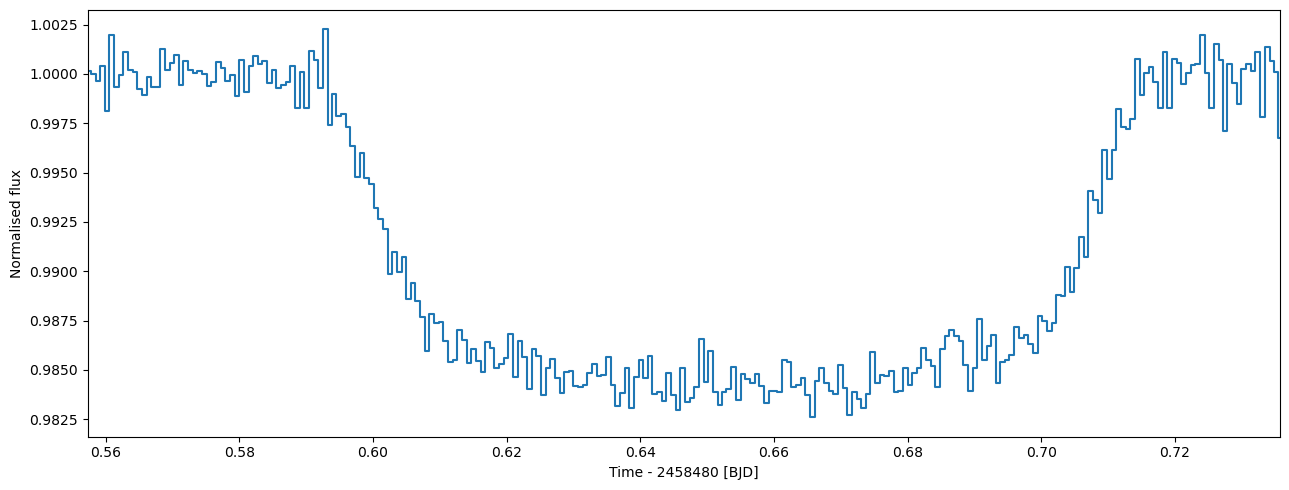

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

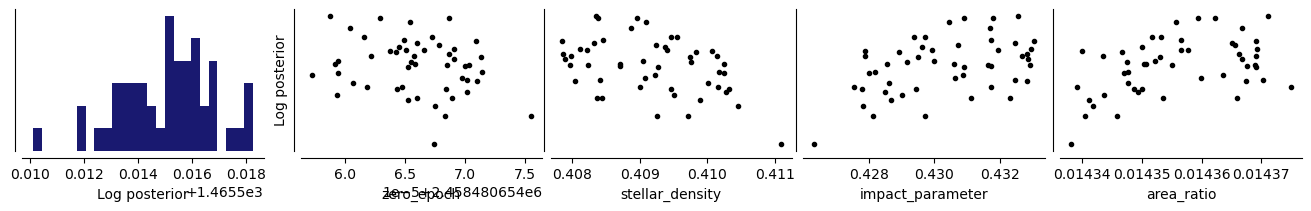

In [7]:
lpf.optimize_global(niter=500, npop=50)

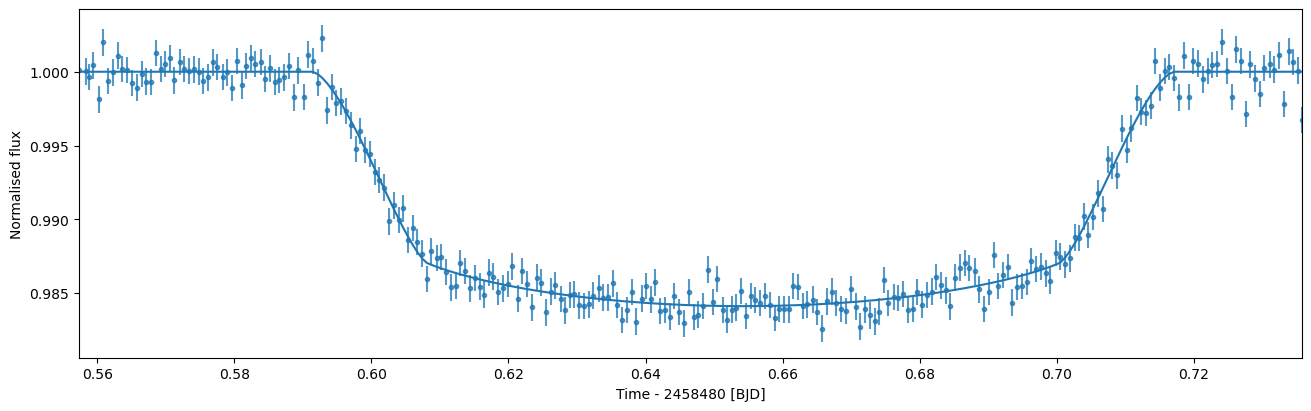

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling: 100%|██████████| 2/2 [00:54<00:00, 27.01s/it] 


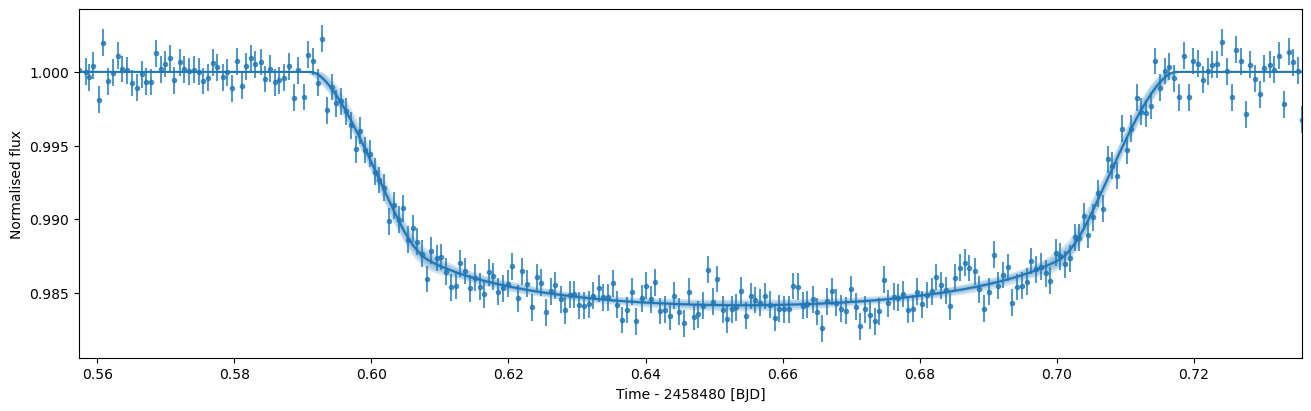

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

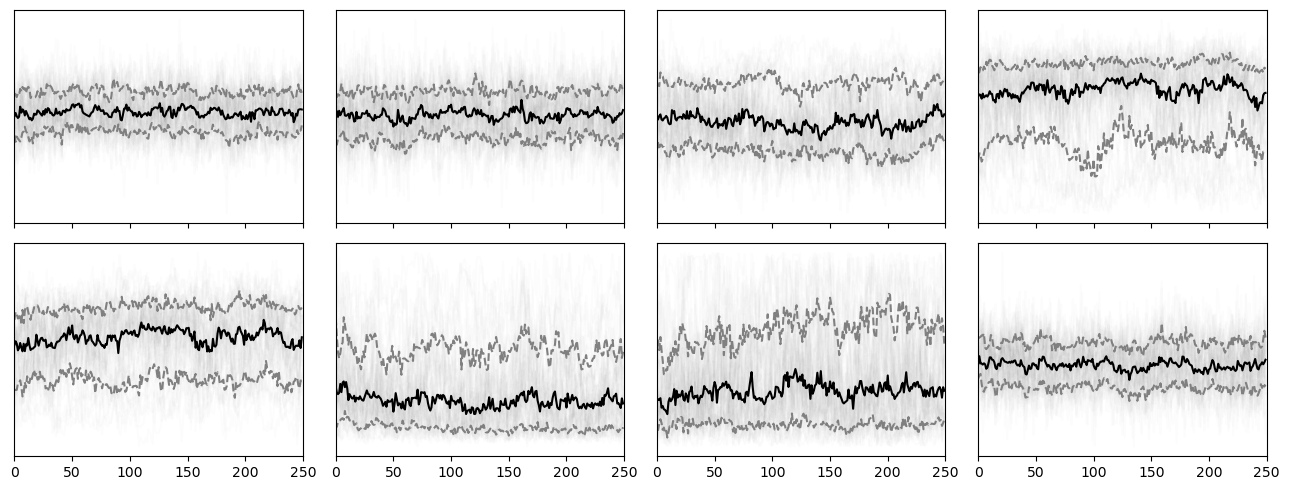

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

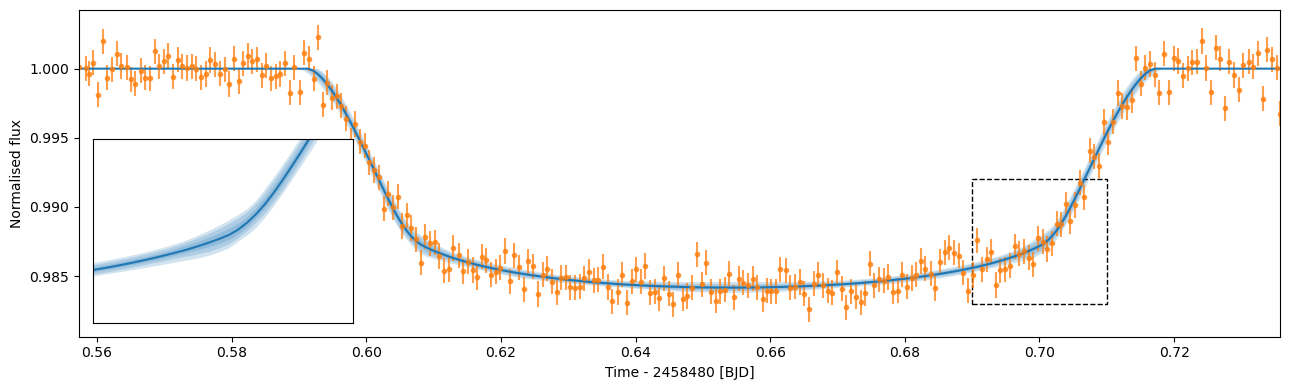

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4342,0.3378,0.0140,0.3202,3.4584e-01,-3.0409,0.1181,3.0103,1.4571,0.1258,0.0946
std,1.6225e-04,1.0952e-09,0.0364,0.1199,0.0005,0.2026,2.4427e-01,0.0196,0.0019,0.0840,0.0425,0.0010,0.0026
min,2.4585e+06,1.0914e+00,0.3295,0.0002,0.0126,0.0412,8.4358e-05,-3.1090,0.1123,2.7479,1.3607,0.1219,0.0862
25%,2.4585e+06,1.0914e+00,0.4073,0.2703,0.0136,0.1605,1.5100e-01,-3.0544,0.1167,2.9490,1.4258,0.1251,0.0926
50%,2.4585e+06,1.0914e+00,0.4309,0.3704,0.0140,0.2662,2.8325e-01,-3.0411,0.1184,3.0050,1.4473,0.1258,0.0943
75%,2.4585e+06,1.0914e+00,0.4620,0.4266,0.0143,0.4309,4.9941e-01,-3.0277,0.1196,3.0756,1.4828,0.1265,0.0966
max,2.4585e+06,1.0914e+00,0.5449,0.5751,0.0151,0.9978,9.9983e-01,-2.9469,0.1229,3.2495,1.5707,0.1305,0.1016


<Axes: >

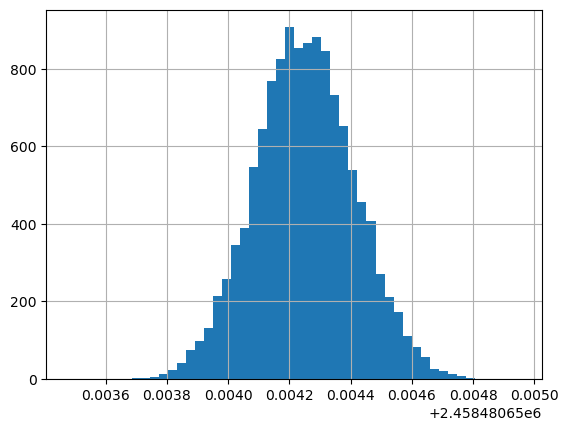

In [16]:
df.tc.hist(bins=50)

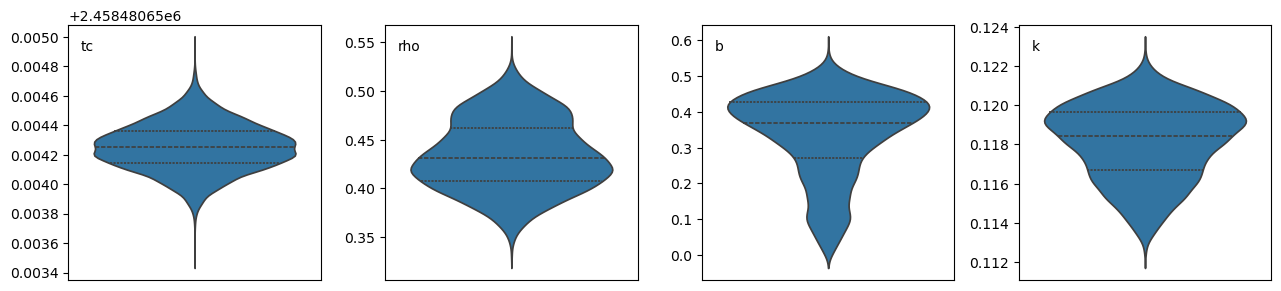

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

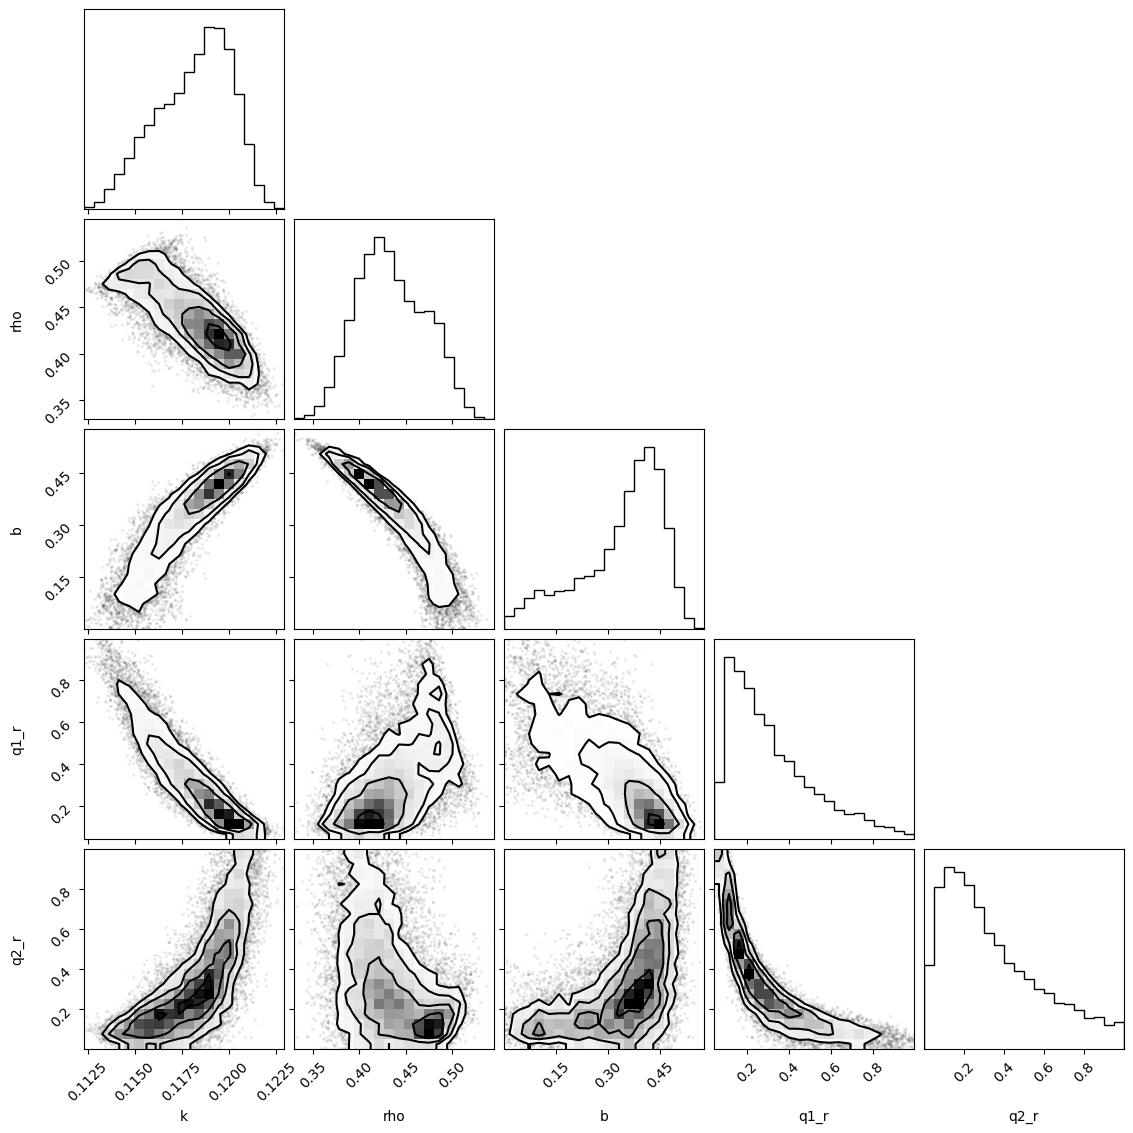

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

The planetary radius can be calculated from the radius ratio $k = R_p / R_\star$
estimated by the transit model:

$$R_p = k \times R_\star$$

To convert the result to Jupiter radii we need the stellar radius from the
literature. Recent studies (e.g. Collins et al. 2017, Stassun et al. 2017) report
a radius of $R_\star = 1.69 \, R_\odot$ for WASP-12. Using the conversion factor
$R_\odot / R_J = 9.731$:

$$R_p \, [R_J] = k \times R_\star \, [R_\odot] \times \frac{R_\odot}{R_J}$$

We apply this formula to all posterior samples of $k$ to propagate the
uncertainty correctly, and report the median with the 16th and 84th percentiles
as the 68% credibility interval ($\pm 1\sigma$ assuming a normal distribution).

In [19]:
#Planetary radius

# Conversion factor
R_sun_to_Rjup = 9.731   # 1 R_sun = 9.731 R_Jup

# Stellar radius from the literature (Collins et al. 2017 / Stassun et al. 2017)
R_star = 1.69           # [R_sun]

# Posterior samples of k (planet-to-star radius ratio) from MCMC
k_samples = df['k'].values

# Planetary radius in R_Jup for each posterior sample
Rp_samples = k_samples * R_star * R_sun_to_Rjup

# Median and 16th/84th percentiles (68% credibility interval)
Rp_med = median(Rp_samples)
Rp_lo  = percentile(Rp_samples, 16)
Rp_hi  = percentile(Rp_samples, 84)

print(f"Radius of WASP-12b:")
print(f"  R_p = {Rp_med:.3f}  +{Rp_hi - Rp_med:.3f} / -{Rp_med - Rp_lo:.3f}  R_Jup")
print(f"\nReference value: ~1.96 R_Jup")

Radius of WASP-12b:
  R_p = 1.948  +0.027 / -0.041  R_Jup

Reference value: ~1.96 R_Jup


2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

The bulk density of a sphere is defined as:

$$\rho_p = \frac{M_p}{\frac{4}{3}\pi R_p^3}$$

Since we now have a transit detection, the orbital inclination is constrained and
$\sin i \approx 1$, so the minimum mass from the radial velocity analysis
($M_p \sin i$) is a good approximation of the true mass.

We model the mass uncertainty from Exercise 1 as a Gaussian with
$M_p \sin i = 1.36 \pm 0.01 \, M_\mathrm{Jup}$ and draw samples from it.
Combined with the posterior samples of $R_p$ from Question 1, we propagate
both uncertainties into the density estimate and report the median and
68% credibility interval.

In [20]:
#Bulk density
from numpy.random import normal

# Planetary mass from RV exercise
M_p_med = 1.36    # [M_Jup]
M_p_err = 0.01    # [M_Jup], symmetric uncertainty

# Draw mass samples from a Gaussian to propagate RV uncertainty
M_p_samples = normal(M_p_med, M_p_err, size=len(Rp_samples))

# Conversion factors
M_jup_kg  = 1.898e27   # 1 M_Jup in kg
R_jup_m   = 7.149e7    # 1 R_Jup in m

# Convert samples to SI
M_si = M_p_samples * M_jup_kg   # [kg]
R_si = Rp_samples  * R_jup_m    # [m]

# Bulk density [kg/m^3]
rho_samples = M_si / (4/3 * mt.pi * R_si**3)

# Median and 16th/84th percentiles
rho_med = median(rho_samples)
rho_lo  = percentile(rho_samples, 16)
rho_hi  = percentile(rho_samples, 84)

print(f"Bulk density of WASP-12b:")
print(f"  rho = {rho_med:.1f}  +{rho_hi - rho_med:.1f} / -{rho_med - rho_lo:.1f}  kg/m^3")
print(f"  rho = {rho_med/1000:.3f}  +{(rho_hi-rho_med)/1000:.3f} / -{(rho_med-rho_lo)/1000:.3f}  g/cm^3")
print(f"\nReference: Jupiter's bulk density ~ 1326 kg/m^3 (1.33 g/cm^3)")

Bulk density of WASP-12b:
  rho = 228.4  +14.9 / -9.6  kg/m^3
  rho = 0.228  +0.015 / -0.010  g/cm^3

Reference: Jupiter's bulk density ~ 1326 kg/m^3 (1.33 g/cm^3)


3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- Answer.
  
Radial velocity measurements only constrain $M_p \sin i$, because the
orbital inclination $i$ is unknown, the same RV signal could be produced
by a massive planet on a face-on orbit or a lighter planet on an edge-on orbit.
A transit can only be observed if the orbital plane is nearly
edge-on as seen from Earth, which geometrically requires $i \approx 90°$ and
therefore $\sin i \approx 1$. This means that the minimum mass becomes
an accurate proxy for the true mass:

$$M_p \sin i \xrightarrow{\text{transit detected}} M_p$$

For WASP-12b, the impact parameter posterior gives $b \ll 1$, confirming
that the orbit is close to edge-on and the approximation is well justified.

#### Would there be better approaches?

Yes. Modelling RVs and photometry separately and then combining the
results is suboptimal for two reasons:

1. **Information loss.** The two datasets share parameters (orbital period,
   time of conjunction, inclination) that are estimated independently and
   then combined, rather than using all the data at once.

2. **Inconsistent uncertainties.** Propagating posteriors from one model
   as fixed inputs into another (as we do here with $M_p \sin i$) ignores
   correlations and can underestimate the true uncertainty.

The main alternative is joint modelling: fitting a single model
to both the RV and photometric time series simultaneously. This brings
fully self-consistent posteriors for all parameters, including the true
mass $M_p$, the radius $R_p$, and the bulk density $\rho_p$, in a single step.
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

- Answer.

Combining all the quantities estimated so far, we can build a coherent
picture of WASP-12b:

Orbital period(extreme orbit).
With $P \approx 1.09$ days, WASP-12b completes a full orbit in just over
26 hours. At this distance ($a \approx 0.023$ AU, only $\sim 3$ stellar radii from the
surface of its host), the planet is subject to extreme tidal forces and
intense irradiation.

Radius(inflated giant).
At $R_p \approx 1.9 \, R_\mathrm{Jup}$, WASP-12b is significantly larger
than Jupiter despite having a comparable mass. Standard planetary structure
models cannot account for this size from internal energy alone; the
inflated radius is thought to be sustained by the intense stellar
irradiation and the tidal heating acumulating energy deep into the atmosphere.

Mass(hot Jupiter).
With $M_p \approx 1.36 \, M_\mathrm{Jup}$, the planet sits firmly in the
hot Jupiter mass range. It is massive enough to have retained its hydrogen
and helium envelope, but not massive enough to be classified as a brown dwarf
($M \gtrsim 13 \, M_\mathrm{Jup}$).

Bulk density(very low-density world).
Bulk density of $\rho_p \lesssim 227.5 \, \mathrm{kg\,m^{-3}}$, well below
Jupiter's $\sim 1326 \, \mathrm{kg\,m^{-3}}$ and even below the density
of water ($1000 \, \mathrm{kg\,m^{-3}}$). This confirms that WASP-12b is
a highly inflated, low-density gas giant with a predominantly gaseous
composition and a likely small or absent dense core.

**Overall picture.**
WASP-12b is an example of a hot Jupiter: a gas giant in a
tidally-locked, decaying orbit that is being slowly disrupted by its host
star. Mass loss through Roche lobe overflow has been observationally
confirmed, and the planet is expected to be engulfed within
$\sim 3$ million years.

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- Answer.

One of the features of transit modelling is that the light curve alone
constrains the mean stellar density $\rho_\star$, without needing to know
the stellar mass or radius independently. This follows from Kepler's third law
combined with the transit geometry:

$$\rho_\star = \frac{3\pi}{G P^2} \left(\frac{a}{R_\star}\right)^3$$

where $a/R_\star$ is the scaled semi-major axis, which is directly related
to the transit duration and shape. The posterior parameter rho in our model
is exactly this quantity, expressed in units of the Solar density
$\rho_\odot = 1408 \, \mathrm{kg\,m^{-3}}$.

We compare this to the theoretical stellar density derived independently
from spectroscopic stellar parameters for WASP-12. Recent spectroscopic analyses
(e.g. Bonomo et al. 2017, HARPS-N) report $\rho_\star = 0.27 \pm 0.01 \, \rho_\odot$,
which we convert to $\mathrm{kg\,m^{-3}}$ for a direct comparison.

Agreement between the two estimates is a consistency check: if the transit model
is well-specified, both values should be compatible within their uncertainties.


In [21]:
#Stellar density

# Solar density [kg/m^3]
rho_sun = 1408.0

# Theoretical stellar density from spectroscopic analysis
# (Bonomo et al. 2017, HARPS-N; rho_star = 0.27 +/- 0.01 rho_sun)
rho_star_theory     = 0.27 * rho_sun   # [kg/m^3]
rho_star_theory_err = 0.01 * rho_sun   # [kg/m^3]

# Transit-derived stellar density from the MCMC posterior
# The model parameter 'rho' is in units of rho_sun
rho_transit_samples = df['rho'].values * rho_sun   # convert to kg/m^3

rho_tr_med = median(rho_transit_samples)
rho_tr_lo  = percentile(rho_transit_samples, 16)
rho_tr_hi  = percentile(rho_transit_samples, 84)

print("Stellar density comparison")

print(f"  Transit (this work):  {rho_tr_med:.1f}  "
      f"+{rho_tr_hi - rho_tr_med:.1f} / -{rho_tr_med - rho_tr_lo:.1f}  kg/m^3")
print(f"  Theory (Bonomo+17):   {rho_star_theory:.1f}  "
      f"+/- {rho_star_theory_err:.1f}  kg/m^3")
print(f"\n  Solar density:        {rho_sun:.0f} kg/m^3  (for reference)")

# Tension in sigma
diff   = rho_tr_med - rho_star_theory
unc    = ((rho_tr_hi - rho_tr_lo) / 2)**2 + rho_star_theory_err**2
tension = diff / unc**0.5
print(f"\n  Difference:  {diff:+.1f} kg/m^3  ({tension:+.1f} sigma)")

Stellar density comparison
  Transit (this work):  606.7  +63.4 / -47.5  kg/m^3
  Theory (Bonomo+17):   380.2  +/- 14.1  kg/m^3

  Solar density:        1408 kg/m^3  (for reference)

  Difference:  +226.5 kg/m^3  (+4.0 sigma)


6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- Answer.

The corner plot reveals several correlations between the model parameters.
The most prominent ones are:

- **$k$ and $b$** (radius ratio and impact parameter): a higher impact parameter
  means the transit chord crosses the stellar disc at a larger angle, making the
  transit shorter and shallower. A larger $k$ can partially compensate for this
  by producing a deeper transit. The two parameters are therefore partially
  degenerate given only the transit depth and duration.

- **$\rho_\star$ and $b$** :the stellar density controls the transit duration
  through the orbital speed (denser star → smaller star for a given mass →
  faster transit). A higher impact parameter also shortens the transit, creating
  a similar observable effect and thus a correlation between the two.

- **$q_1$ and $q_2$** (limb darkening coefficients): these two parameters
  describe the centre-to-limb brightness profile of the star and are intrinsically
  coupled, changing one can be compensated by adjusting the other to produce a
  similar integrated profile over the transit chord.

In practice, correlated parameters mean that marginal uncertainties alone are not enough, taking into account the 1D posterior width of each parameter ignores the fact that certain combinations are much better constrained than others. This is why derived quantities ($R_p$ or $\rho_p$) must be computed sample by sample. Finally, correlations can be reduced by adding independent data: spestrocopic parameters constrain $\rho_\star$, multi-band photometry constrains limb darkening, and high resolution imaging can rule out blended companions.

---
<center>&copy;2026 Hannu Parviainen</center>